# MECH 309: Assignment 5, Question 2

_Cagri Arslan_

March 12, 2026

*All work can be found on https://github.com/imported-canuck/MECH-309*

In [1]:
# Imports
import numpy as np
from matplotlib import pyplot as plt
from scipy import linalg

plt.style.use("bmh") # plotting style

# a)

Using each data pair $(t_i, T_i)$ and the model
$$
T(t)=T_E+(T_0-T_E)\exp(-kt),
$$
we have
$$
T_i = T_E + (T_0 - T_E)\exp(-k t_i), \qquad i=\alpha,\alpha+1,\dots,\beta.
$$

Let
$$
\mathbf{x}=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
=
\begin{bmatrix}
T_0\\
k
\end{bmatrix}.
$$

Then the nonlinear least-squares problem
$$
\min_{\mathbf{x}} J(\mathbf{x})=\frac{1}{2}\|\mathbf{b}-\mathbf{f}(\mathbf{x})\|_2^2
$$
has

$$
\mathbf{b}=
\begin{bmatrix}
T_\alpha\\
T_{\alpha+1}\\
\vdots\\
T_\beta
\end{bmatrix},
\qquad
\mathbf{f}(\mathbf{x})=
\begin{bmatrix}
T_E+(x_1-T_E)\exp(-x_2 t_\alpha)\\
T_E+(x_1-T_E)\exp(-x_2 t_{\alpha+1})\\
\vdots\\
T_E+(x_1-T_E)\exp(-x_2 t_\beta)
\end{bmatrix}.
$$

Equivalently, since $\mathbf{x}=[T_0\ k]^T$,
$$
\mathbf{f}(\mathbf{x})=
\begin{bmatrix}
T_E+(T_0-T_E)\exp(-k t_\alpha)\\
T_E+(T_0-T_E)\exp(-k t_{\alpha+1})\\
\vdots\\
T_E+(T_0-T_E)\exp(-k t_\beta)
\end{bmatrix}.
$$

# b)

From part (a), define
$$
\mathbf{f}(\mathbf{x})=
\begin{bmatrix}
f_\alpha(\mathbf{x})\\
f_{\alpha+1}(\mathbf{x})\\
\vdots\\
f_\beta(\mathbf{x})
\end{bmatrix}
=
\begin{bmatrix}
T_E+(T_0-T_E)\exp(-k t_\alpha)\\
T_E+(T_0-T_E)\exp(-k t_{\alpha+1})\\
\vdots\\
T_E+(T_0-T_E)\exp(-k t_\beta)
\end{bmatrix},
\qquad
\mathbf{x}=
\begin{bmatrix}
T_0\\
k
\end{bmatrix}.
$$

The Jacobian matrix is
$$
\mathbf{A}(\mathbf{x})=\frac{\partial \mathbf{f}}{\partial \mathbf{x}}
=
\begin{bmatrix}
\frac{\partial f_\alpha}{\partial x_1} & \frac{\partial f_\alpha}{\partial x_2}\\
\frac{\partial f_{\alpha+1}}{\partial x_1} & \frac{\partial f_{\alpha+1}}{\partial x_2}\\
\vdots & \vdots\\
\frac{\partial f_\beta}{\partial x_1} & \frac{\partial f_\beta}{\partial x_2}
\end{bmatrix}.
$$

Since
$$
f_i(\mathbf{x})=T_E+(x_1-T_E)\exp(-x_2 t_i),
$$
we get
$$
\frac{\partial f_i}{\partial x_1}=\exp(-x_2 t_i),
\qquad
\frac{\partial f_i}{\partial x_2}=-t_i(x_1-T_E)\exp(-x_2 t_i).
$$

Therefore,
$$
\mathbf{A}(\mathbf{x})=
\begin{bmatrix}
\exp(-x_2 t_\alpha) & -t_\alpha(x_1-T_E)\exp(-x_2 t_\alpha)\\
\exp(-x_2 t_{\alpha+1}) & -t_{\alpha+1}(x_1-T_E)\exp(-x_2 t_{\alpha+1})\\
\vdots & \vdots\\
\exp(-x_2 t_\beta) & -t_\beta(x_1-T_E)\exp(-x_2 t_\beta)
\end{bmatrix}.
$$

Equivalently, since $\mathbf{x}=[T_0\ k]^T$,
$$
\mathbf{A}(\mathbf{x})=
\begin{bmatrix}
\exp(-k t_\alpha) & -t_\alpha(T_0-T_E)\exp(-k t_\alpha)\\
\exp(-k t_{\alpha+1}) & -t_{\alpha+1}(T_0-T_E)\exp(-k t_{\alpha+1})\\
\vdots & \vdots\\
\exp(-k t_\beta) & -t_\beta(T_0-T_E)\exp(-k t_\beta)
\end{bmatrix}.
$$

# c)
Once again, we consider the nonlinear least squares problem of the form:

$$
\mathbf{f}(\mathbf{x})=\mathbf{b}
$$

We solve this using:

$$
\mathbf{A}(\overline{\mathbf{x}})^{\mathsf{T}}\mathbf{A}(\overline{\mathbf{x}})\delta\mathbf{x}=\mathbf{A}(\overline{\mathbf{x}})^{\mathsf{T}}(\mathbf{b}-\mathbf{f}(\overline{\mathbf{x}}))
$$

As this is a nonlinear least squares problem, we solve it iteratively with the Gauss-Newton algorithm as such:

$$
\mathbf{A}^{\mathsf{T}}_{i}\mathbf{A}_{i}\delta\mathbf{x}_{i}=\mathbf{A}^{\mathsf{T}}_{i}(\mathbf{b}-\mathbf{f}({\mathbf{x}}_{i})) \\
\mathbf{x}_{i+1} = \mathbf{x}_{i} + \delta \mathbf{x}_{i}
$$

Starter code is provided in ```cooling_nls.py```. As this is a Jupyter notebook, the code block below consists of the functions in ```cooling_nls.py```, with "TODO" sections completed. Credit is given to Prof. Nicolai for the starter code. 

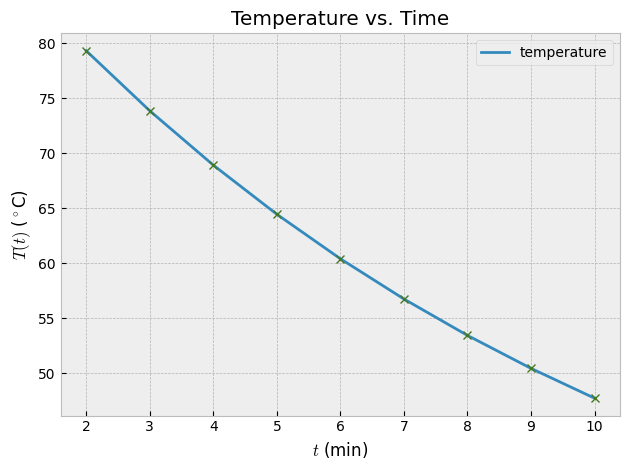

Converged value is [[92.   0.1]]
Number of iterations is 5


In [2]:
def f_temp(T0, TE, k, t):
    # Newton's law of cooling
    return TE + (T0 - TE) * np.exp(-k * t)


def Jacobian(T0, TE, k, t):
    # Jacobian wrt T0 and k associated with Newton's law of cooling
    J1 = np.exp(-k * t)  # derivative wrt T0
    J2 = -t * (T0 - TE) * np.exp(-k * t)   # derivative wrt k
    return np.array([J1, J2])

# Load and extract data
data = np.loadtxt(
    'temp_vs_time.csv',
    dtype=float,
    delimiter=',',
    skiprows=1,
    usecols=(0, 1,)
    )

t = data[:, 0]  # minutes (inconsistency in provided data, helper says seconds)
T = data[:, 1]  # temperature

def main(): 
    fig, ax = plt.subplots()
    ax.set_title(r'Temperature vs. Time')
    ax.set_xlabel(r'$t$ (min)')
    ax.set_ylabel(r'$T(t)$ ($^\circ$C)')
    ax.plot(t, T, label='temperature', color='C0')
    ax.plot(t, T, 'x', color='C3')
    ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()

    # Form the nonlinear least squares problem A.T @ A @ dx = A.T @ (y - f(x))
    # Extract dimensions of Jacobian matrix
    m = T.shape[0]
    n = 2

    TE = 22  # environment temperature
    eps1 = 1e-6
    Nmax = 10

    b = T.reshape(-1, 1) # Measurement vector, reshaped into 2D
    A = np.zeros((m, n))  # Jacobian matrix

    j = 0 # Initialize counter

    b_hat = np.zeros((m, 1))  # model prediction
    x_hat = np.array([[98],
                      [0.05]])  # initial guess for T0 and k

    delta_x = np.array([[1],
                        [0.0]])  # initial delta_x

    # Nonlinear least squares loop
    while (linalg.norm(delta_x, 2) > eps1) and (j < Nmax):

        T0_hat = x_hat[0, 0]
        k_hat = x_hat[1, 0]

        # Compute model prediction
        b_hat = f_temp(T0_hat, TE, k_hat, t).reshape(-1, 1)

        # Build Jacobian matrix
        A = Jacobian(T0_hat, TE, k_hat, t).T

        # Solve linearized least squares problem
        delta_x = linalg.solve(A.T @ A, A.T @ (b - b_hat))

        # Update solution
        x_hat = x_hat + delta_x
        
        # Counter update
        j += 1

    print("Converged value is", x_hat.T)
    print("Number of iterations is", j)

main()

As presented, the Gauss-Newton algorithm converged in 5 iterations with the provided tolerance & initial estimation vector. The resultant parameter vector $\mathbf{x}$ is:

$$
\mathbf{x}=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
=
\begin{bmatrix}
T_0\\
k
\end{bmatrix}
\approx
\begin{bmatrix}
92\\
0.1
\end{bmatrix}.
$$

And so the fitted curve is:

$$
T(t) = 22 + 70e^{-t/10}
$$

We plot the fitted curve against the given points to visually verify that the model is indeed a good fit.  

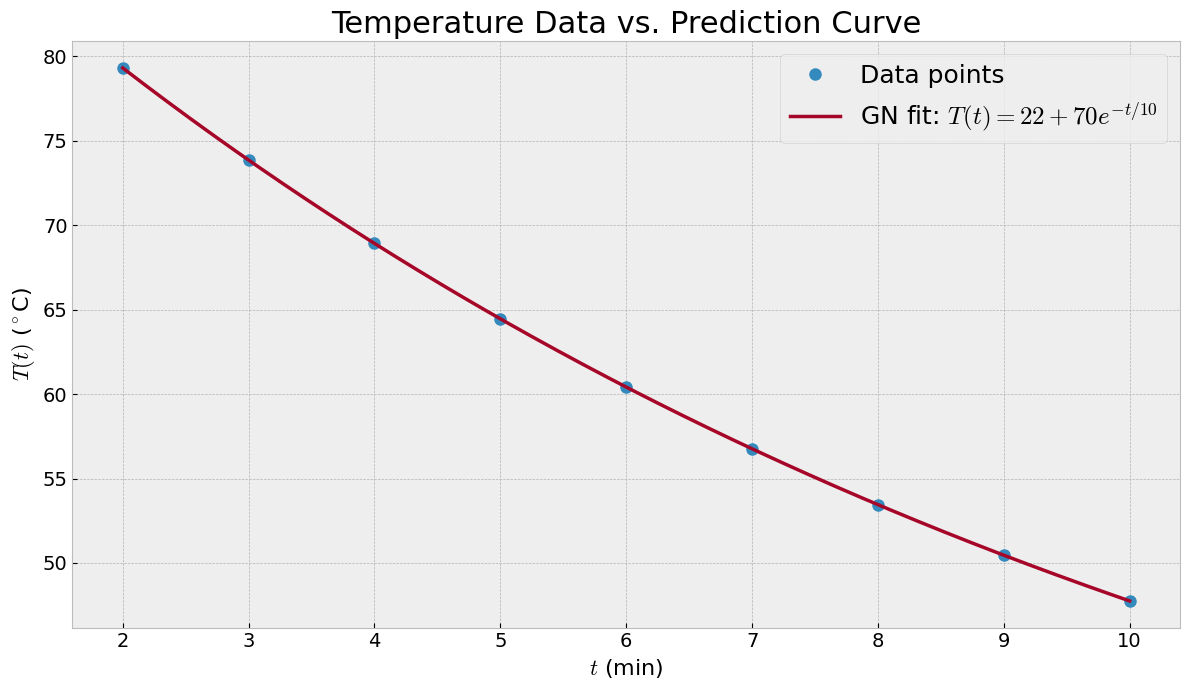

In [3]:
# Prediction curve: T(t) = 22 + 70 e^(-t/10)
t_plot = np.linspace(np.min(t), np.max(t), 400)
T_pred = 22 + 70 * np.exp(-t_plot / 10)

fig, ax = plt.subplots()
fig.set_size_inches(12, 7, forward=True)

ax.set_title(r"Temperature Data vs. Prediction Curve", fontsize=22)
ax.set_xlabel(r"$t$ (min)", fontsize=16)
ax.set_ylabel(r"$T(t)$ ($^\circ$C)", fontsize=16)

ax.plot(t, T, 'o', markersize=8, label='Data points')
ax.plot(t_plot, T_pred, '-', linewidth=2.5, label=r'GN fit: $T(t)=22+70e^{-t/10}$')

ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=18)
fig.tight_layout()
plt.show()

# d)

We now have the fitted function:

$$
T(t) = 22+70\exp(-t/10)
$$

We seek to find the time $t$ such that $T(t) = 35$. This is equivalent to finding the root of $G(t) = T(t)-35 = 22+70\exp(-t/10)-35 = -13+70\exp(-t/10)$. Before we begin, we first prove the *existence* and *uniqueness* of the solution $G(t) = 0$. 

**Existence:** Consider $G(20) = -13+70\exp(-2) \approx -3.53 < 0$ and $G(10) = -13+70\exp(-1) \approx 12.75 > 0$. Additionally, $G(t)$ is continuous $\forall x \in \mathbb{R}$ and is especially continuous $\forall x \in [10, 20]$. Therefore, by the Intermediate Value Theorem $\exists x \in [10, 20] : G(x) = 0$.

**Uniqueness:** Consider $\frac{dG}{dt} = -7\exp(-t/10) < 0$ $\forall x \in \mathbb{R}$. Hence, $G(t)$ is continuously decreasing on all $\mathbb{R}$. Therefore, *if* there is a root (there is), there can only be one root, as the function will never be able to increase back above 0. 

Therefore, we have shown that $G(t)$ has one, and only one root. We can thus use the bisection method to estimate the root of $G(t)$ using $a=10$, $b=20$. We choose bisection since it is simple, robust, and guarenteed to converge once a valid interval, that is, [10, 20] has been established. We code it below:

In [4]:
def bisection(a, b, f, tol = 1e-6, max_iter = 100):
    '''
    Bisection method to find a root of the function f in the interval [a, b].

    Parameters:
        a (float): Left endpoint of the interval.
        b (float): Right endpoint of the interval.
        f (callable): The function for which we want to find a root.
        tol (float): Tolerance for convergence. The method stops when |f(m)| <
        tol, where m is the midpoint of the interval.
        max_iter (int): Maximum number of iterations to prevent infinite loops.
    
    Returns:
        float: Approximate root of the function f.
        int: Number of iteratons taken to converge. 
    '''
    # Validate f(a) and f(b) have opposite signs
    if f(a) * f(b) >= 0: 
        print("Bisection method fails.")
        return None
    
    i = 0 # Initalize counter

    # Bisection algorithm
    while i < max_iter: # Iterate until limit iterations
        m = a + (b - a) / 2 # Determine midpoint x value between a and b
        # If sign of m is same as that of a, replace a with m 
        if np.sign(f(m)) == np.sign(f(a)): 
            a = m
        # Otherwise, replace b with m (as b must have same sign as m)
        else:
            b = m
        # Check if f(m) is sufficiently close to 0, stop if it is
        if abs(f(m)) < tol:
            print(f"Converged to root {m} in {i+1} iterations.")
            # Return i+1 as counter since counter starts at 0, not 1
            return m, i+1
        i += 1
    
    # If optimizser never converges, warn and return final step. 
    if i == max_iter:
        print(f"Reached maximum iterations. Approximate root is {m}.")
        return m, i 

We now define the function $G(x)$ and call the bisection function on it.

In [5]:
def g(t):
    '''
    Function g(t) = T(t) - 35, where T(t) is the temperature prediction curve.
    '''
    return -13 + 70 * np.exp(-t / 10)

# Call bisection function on our best fit curve
root, iterations = bisection(10, 20, g)

print("=" * 40)
print("      Bisection Method Results")
print("=" * 40)
print(f"{'Root t_des':<18}= {root:.6f}")
print(f"{'Iterations':<18}= {iterations}")
print(f"{'g(t_des)':<18}= {g(root):.6e}")
print("=" * 40)

Converged to root 16.835458278656006 in 22 iterations.
      Bisection Method Results
Root t_des        = 16.835458
Iterations        = 22
g(t_des)          = 7.373889e-07


As seen above, the bisection algorithm converges to a root of approximately 16.835 after 22 iterations. The residual is very low, to the order of $10^{-7}$, below our defined tolerance of $10^{-6}$. This means that $G(t) \approx 0$ when $t = 16.835$. Hence, $T(t) \approx 35^{\circ} C$ when $t = 16.835$ minutes.